In [1]:
# Inštalácia potrebných knižníc
!pip install tensorflow-cpu xgboost imbalanced-learn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.44.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [2]:
# Import knižníc potrebných na prácu s dátami, vizualizáciu, predspracovanie, modelovanie a vyhodnotenie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix, recall_score, precision_score,
    f1_score, roc_auc_score, precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import keras
from keras import layers

In [ ]:
# Načítanie datasetu a jeho základná kontrola
data = pd.read_csv('creditcard.csv')
print('Tvar datasetu:', data.shape)
data.head()

Tvar datasetu: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Kontrola chýbajúcich hodnôt v stĺpcoch datasetu
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
# Zobrazenie základných informácií o datasete, dátových typoch a počte neprázdnych hodnôt
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
# Výpočet základných štatistických charakteristík numerických atribútov
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


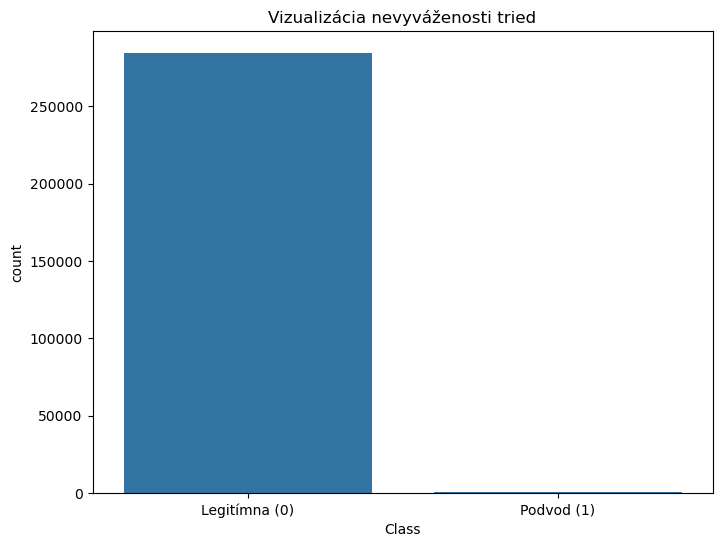

In [7]:
# Vizualizácia rozdelenia cieľovej premennej Class, overenie nevyváženosti tried
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=data)
plt.title('Vizualizácia nevyváženosti tried')
plt.xticks([0, 1], ['Legitímna (0)', 'Podvod (1)'])
plt.show()

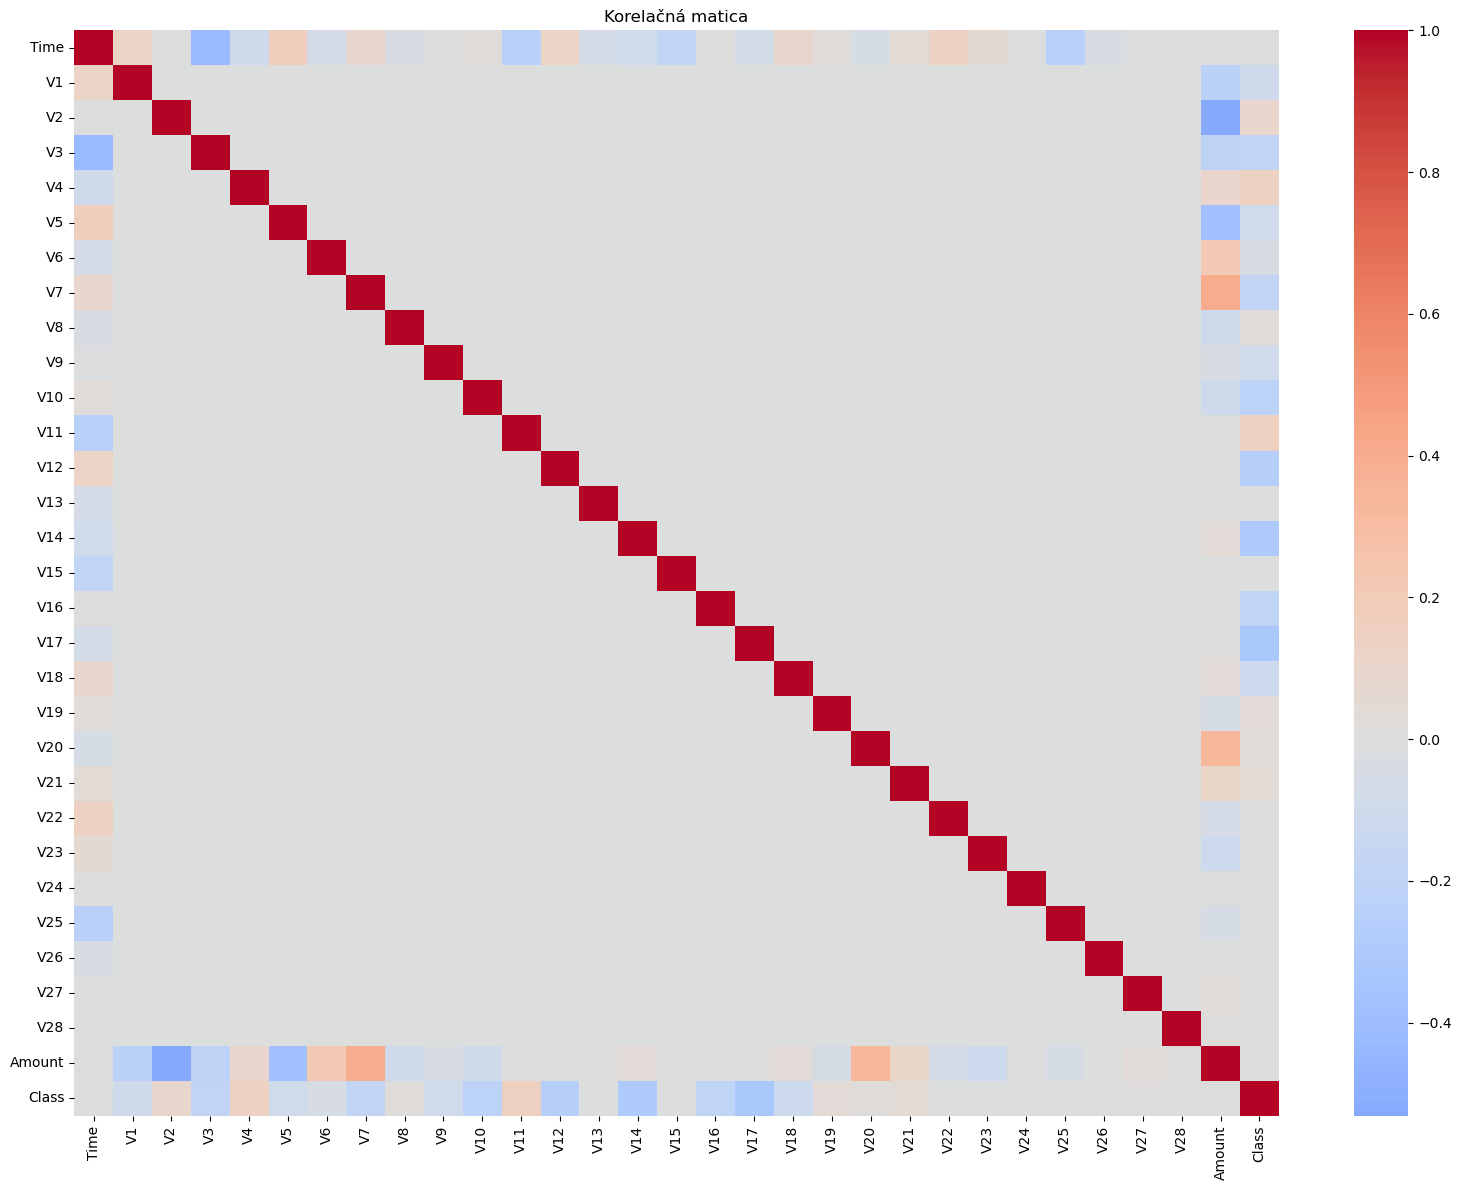

In [8]:
# Korelačná matica, preskúmanie vzťahov medzi atribútmi datasetu
plt.figure(figsize=(16, 12))
sns.heatmap(data.corr(), cmap='coolwarm', center=0)
plt.title('Korelačná matica')
plt.tight_layout()
plt.show()

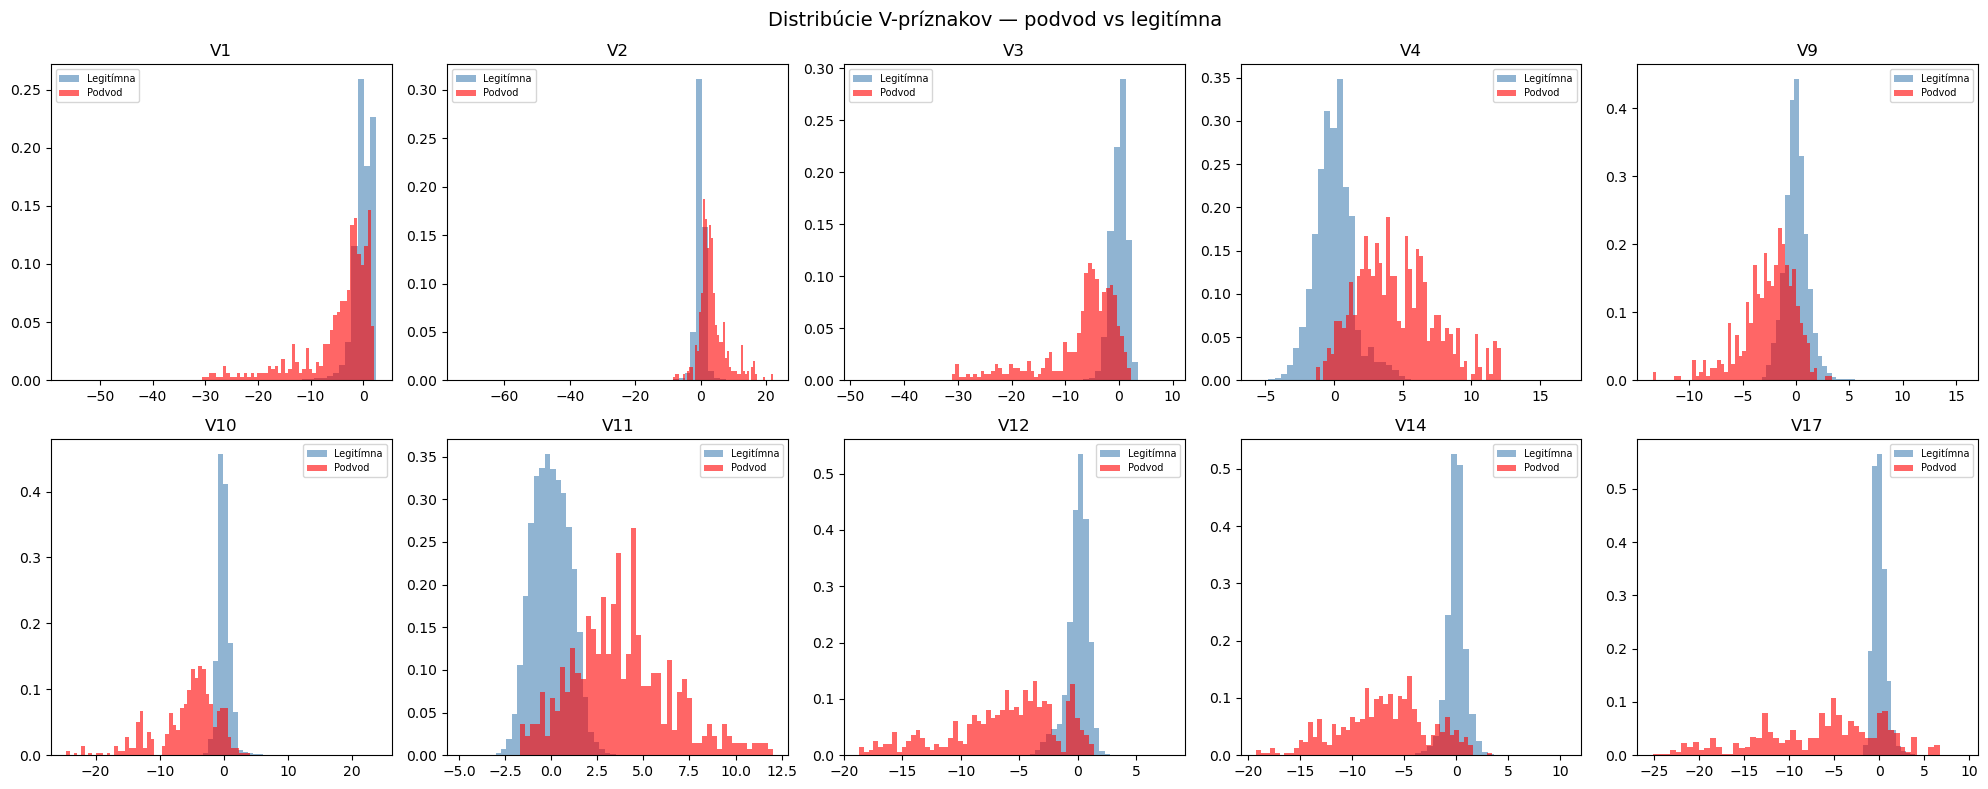

In [9]:
# Porovnanie distribúcií vybraných PCA atribútov podľa triedy transakcie
v_features = ['V1', 'V2', 'V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V17']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(v_features):
    axes[i].hist(data[data['Class'] == 0][col], bins=50, alpha=0.6, color='steelblue', label='Legitímna', density=True)
    axes[i].hist(data[data['Class'] == 1][col], bins=50, alpha=0.6, color='red', label='Podvod', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribúcie V-príznakov — podvod vs legitímna', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Odstránenie duplicitných a prípadných chýbajúcich záznamov z datasetu
data = data.drop_duplicates()
data = data.dropna()
print('Tvar po čistení:', data.shape)

Tvar po čistení: (283726, 31)


In [11]:
# Vytvorenie časových príznakov odvodených z atribútu Time
data['Hour'] = (data['Time'] // 3600) % 24

data['Transactions_per_hour'] = data.groupby('Hour')['Hour'].transform('count')
data['Avg_amount_per_hour'] = data.groupby('Hour')['Amount'].transform('mean')
data['Log_amount'] = np.log1p(data['Amount'])

print('Nové príznaky pridané. Nový tvar datasetu:', data.shape)
print('Nové stĺpce:', ['Hour', 'Transactions_per_hour', 'Avg_amount_per_hour', 'Log_amount'])

Nové príznaky pridané. Nový tvar datasetu: (283726, 35)
Nové stĺpce: ['Hour', 'Transactions_per_hour', 'Avg_amount_per_hour', 'Log_amount']


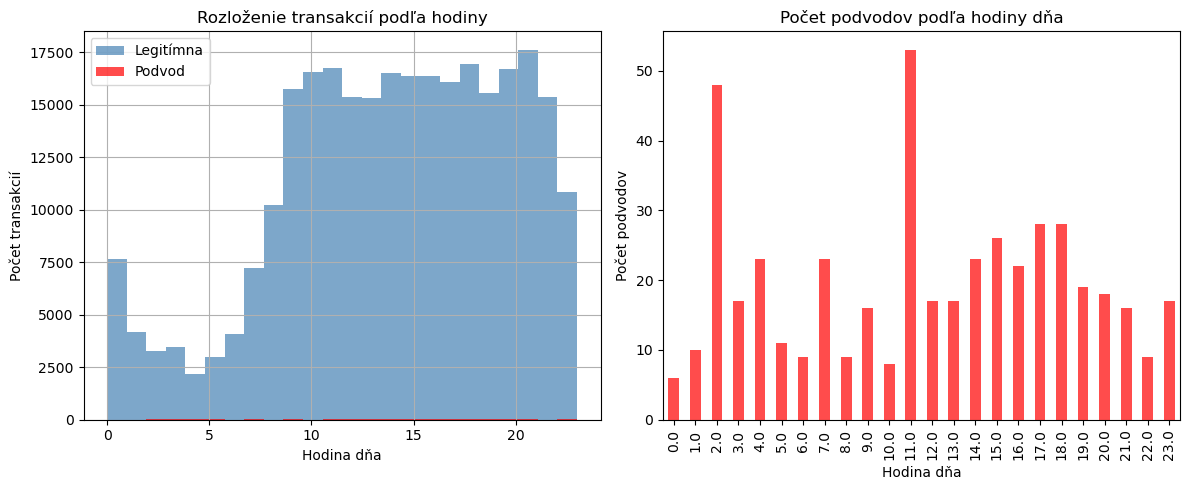

In [12]:
# Vizualizácia rozloženia transakcií a podvodov podľa hodiny dňa
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
data[data['Class'] == 0]['Hour'].hist(bins=24, color='steelblue', alpha=0.7, label='Legitímna')
data[data['Class'] == 1]['Hour'].hist(bins=24, color='red', alpha=0.7, label='Podvod')
plt.xlabel('Hodina dňa')
plt.ylabel('Počet transakcií')
plt.title('Rozloženie transakcií podľa hodiny')
plt.legend()

plt.subplot(1, 2, 2)
fraud_by_hour = data[data['Class'] == 1].groupby('Hour').size()
fraud_by_hour.plot(kind='bar', color='red', alpha=0.7)
plt.xlabel('Hodina dňa')
plt.ylabel('Počet podvodov')
plt.title('Počet podvodov podľa hodiny dňa')

plt.tight_layout()
plt.show()

In [13]:
# Oddelenie vstupných atribútov od cieľovej premennej Class
X = data.drop('Class', axis=1)
y = data['Class']

In [14]:
# Rozdelenie dát na trénovaciu a testovaciu množinu so zachovaním pomeru tried, následné škálovanie atribútov
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Veľkosť trénovacej sady: ', X_train_scaled.shape)
print('Veľkosť testovacej sady: ', X_test_scaled.shape)
print('Pomer podvodov v train: ', round(y_train.mean(), 4))
print('Pomer podvodov v test: ', round(y_test.mean(), 4))

Veľkosť trénovacej sady:  (198608, 34)
Veľkosť testovacej sady:  (85118, 34)
Pomer podvodov v train:  0.0017
Pomer podvodov v test:  0.0017


In [15]:
# Vytvorenie validačnej množiny z trénovacích dát na ladenie rozhodovacieho prahu
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print('Veľkosť trenovacej sady (bez val): ', X_tr.shape)
print('Veľkosť validačnej sady: ', X_val.shape)

Veľkosť trenovacej sady (bez val):  (158886, 34)
Veľkosť validačnej sady:  (39722, 34)


In [16]:
# Aplikácia metódy SMOTE na trénovaciu množinu na vyrovnanie tried
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_tr, y_tr)

print('Pred SMOTE: ', y_tr.value_counts().to_dict())
print('Po SMOTE: ', dict(zip(*np.unique(y_train_smote, return_counts=True))))

Pred SMOTE:  {0: 158621, 1: 265}
Po SMOTE:  {0: 158621, 1: 158621}


In [17]:
# Definovanie pomocných funkcií na výpočet EFL, vyhodnotenie modelov a hľadanie vhodného rozhodovacieho prahu
def compute_efl(y_true, y_pred, c_fp=5, c_fn=100):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp * c_fp + fn * c_fn


def evaluate_model(y_true, y_pred, model_name='Model'):
    print(f'--- {model_name} ---')
    print(f'Návratnosť: {recall_score(y_true, y_pred):.4f}')
    print(f'Presnosť: {precision_score(y_true, y_pred):.4f}')
    print(f'F1: {f1_score(y_true, y_pred):.4f}')
    print(f'EFL: {compute_efl(y_true, y_pred)}')
    print()


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitímna', 'Podvod'], yticklabels=['Legitímna', 'Podvod'])
    plt.title(title)
    plt.xlabel('Predpovedaná')
    plt.ylabel('Skutočná')
    plt.tight_layout()
    plt.show()


def find_best_threshold_recall(y_true, y_proba, min_precision=0.1):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    best_threshold = 0.5
    best_recall = 0
    for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
        if p >= min_precision and r > best_recall:
            best_recall = r
            best_threshold = t
    return best_threshold

--- Baseline ---
Návratnosť: 0.8873
Presnosť: 0.0516
F1: 0.0975
EFL: 13180



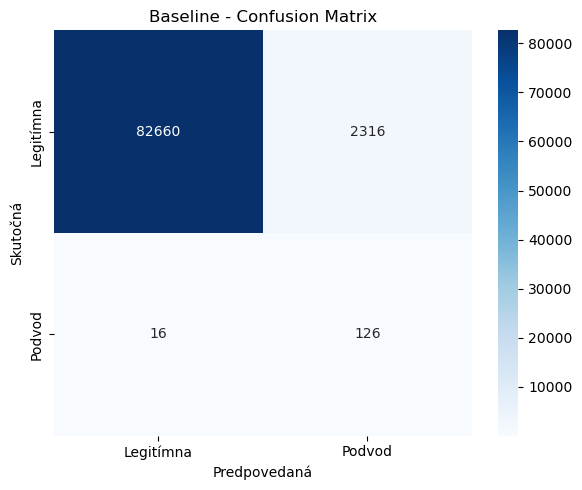

In [18]:
# Trénovanie baseline modelu a jeho vyhodnotenie na testovacích dátach
baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline.fit(X_tr, y_tr)

y_pred_base  = baseline.predict(X_test_scaled)
y_proba_base = baseline.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, y_pred_base, 'Baseline')
plot_confusion_matrix(y_test, y_pred_base, 'Baseline - Confusion Matrix')

Optimálny threshold (z val. sady): 0.7094
--- Baseline - threshold tuned ---
Návratnosť: 0.8873
Presnosť: 0.0984
F1: 0.1772
EFL: 7370



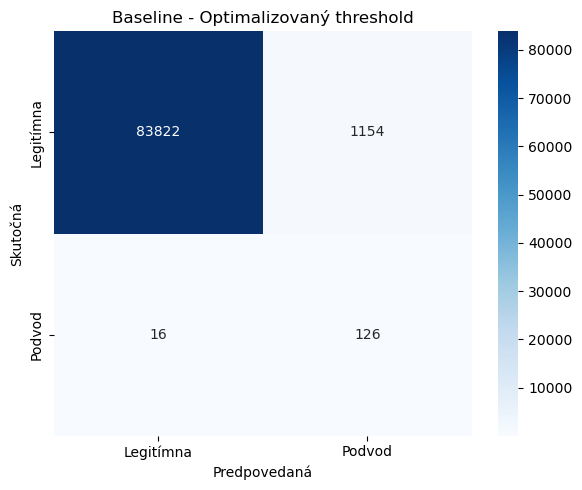

In [19]:
# Ladenie rozhodovacieho prahu logistickej regresie na validačnej množine a vyhodnotenie upraveného modelu
y_proba_val_base = baseline.predict_proba(X_val)[:, 1]
best_thresh_base  = find_best_threshold_recall(y_val, y_proba_val_base, min_precision=0.1)

y_pred_base_tuned = (y_proba_base >= best_thresh_base).astype(int)

print(f'Optimálny threshold (z val. sady): {best_thresh_base:.4f}')
evaluate_model(y_test, y_pred_base_tuned, 'Baseline - threshold tuned')
plot_confusion_matrix(y_test, y_pred_base_tuned, 'Baseline - Optimalizovaný threshold')

--- XGBoost ---
Návratnosť: 0.7535
Presnosť: 0.9554
F1: 0.8425
EFL: 3525



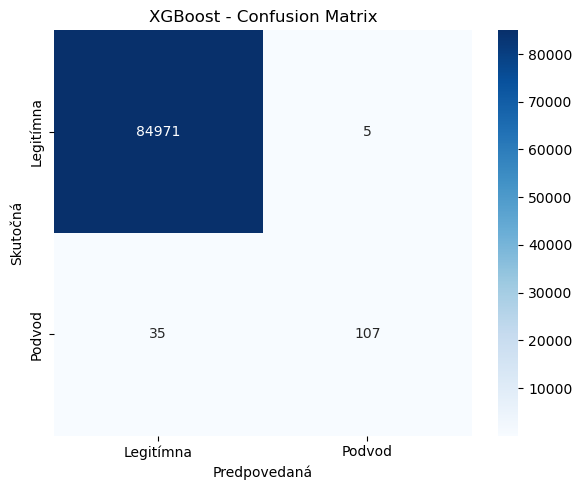

In [20]:
# Trénovanie modelu XGBoost s váhovaním menšinovej triedy
model_xgb = xgb.XGBClassifier(
    scale_pos_weight=50,
    eval_metric='logloss',
    random_state=42
)
model_xgb.fit(X_tr, y_tr)

y_pred_xgb  = model_xgb.predict(X_test_scaled)
y_proba_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, y_pred_xgb, 'XGBoost')
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost - Confusion Matrix')

--- XGBoost - SMOTE ---
Návratnosť: 0.7746
Presnosť: 0.8943
F1: 0.8302
EFL: 3265



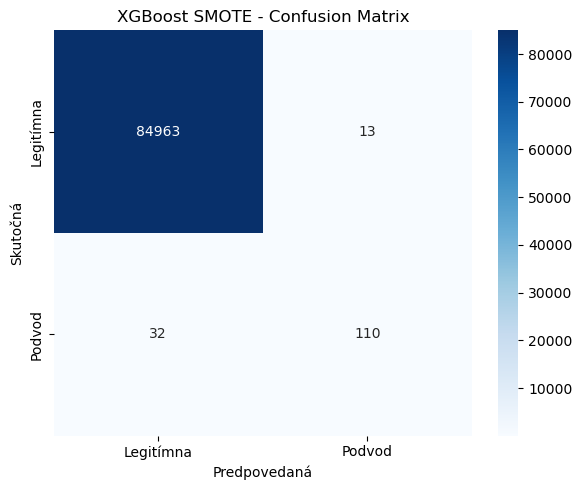

In [21]:
# Trénovanie modelu XGBoost na dátach upravených metódou SMOTE
model_xgb_smote = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42
)
model_xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote  = model_xgb_smote.predict(X_test_scaled)
y_proba_xgb_smote = model_xgb_smote.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, y_pred_xgb_smote, 'XGBoost - SMOTE')
plot_confusion_matrix(y_test, y_pred_xgb_smote, 'XGBoost SMOTE - Confusion Matrix')

In [22]:
# Optimalizácia hyperparametrov modelu XGBoost pomocou RandomizedSearchCV
param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [50, 100, 200],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_tr, y_tr)

print('\nNajlepšie hyperparametre:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nNajlepší CV Recall: {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Najlepšie hyperparametre:
  scale_pos_weight: 50
  n_estimators: 100
  max_depth: 3
  learning_rate: 0.05

Najlepší CV Recall: 0.8528


--- XGBoost - optimalizovaný ---
Návratnosť: 0.8169
Presnosť: 0.5979
F1: 0.6905
EFL: 2990



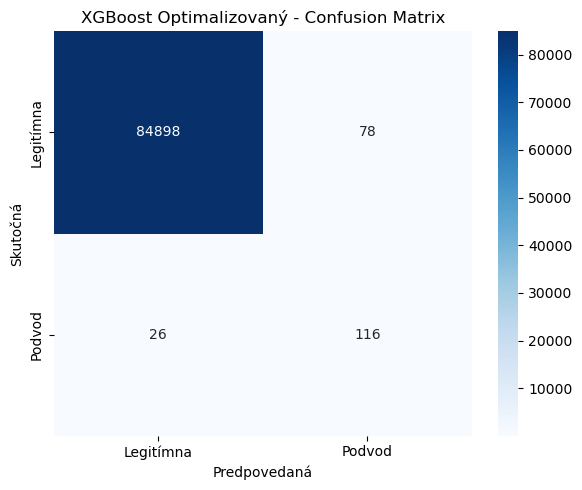

In [23]:
# Vyhodnotenie optimalizovaného modelu XGBoost na testovacej množine
best_xgb = xgb_search.best_estimator_

y_pred_xgb_opt  = best_xgb.predict(X_test_scaled)
y_proba_xgb_opt = best_xgb.predict_proba(X_test_scaled)[:, 1]

evaluate_model(y_test, y_pred_xgb_opt, 'XGBoost - optimalizovaný')
plot_confusion_matrix(y_test, y_pred_xgb_opt, 'XGBoost Optimalizovaný - Confusion Matrix')

Optimálny threshold (z val. sady): 0.0872
--- XGBoost - optimalizovaný + threshold tuning ---
Návratnosť: 0.8732
Presnosť: 0.1026
F1: 0.1836
EFL: 7225



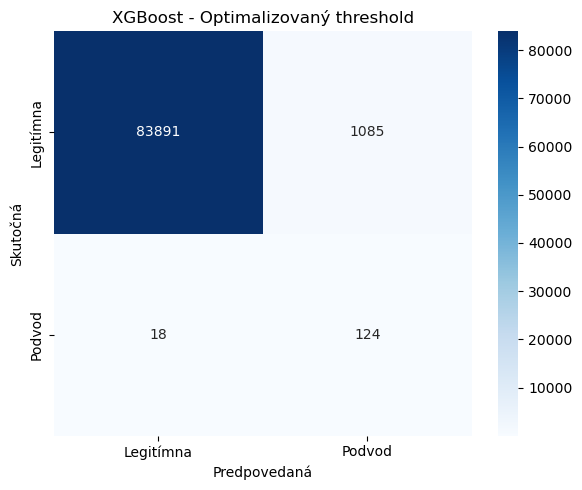

In [24]:
# Ladenie rozhodovacieho prahu optimalizovaného modelu XGBoost a jeho následné vyhodnotenie
y_proba_val_xgb_opt = best_xgb.predict_proba(X_val)[:, 1]
best_thresh_xgb  = find_best_threshold_recall(y_val, y_proba_val_xgb_opt, min_precision=0.1)

y_pred_xgb_tuned = (y_proba_xgb_opt >= best_thresh_xgb).astype(int)

print(f'Optimálny threshold (z val. sady): {best_thresh_xgb:.4f}')
evaluate_model(y_test, y_pred_xgb_tuned, 'XGBoost - optimalizovaný + threshold tuning')
plot_confusion_matrix(y_test, y_pred_xgb_tuned, 'XGBoost - Optimalizovaný threshold')

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - Precision: 0.0072 - Recall: 0.1358 - loss: 0.1520 - val_Precision: 1.0000 - val_Recall: 0.0455 - val_loss: 0.0254
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - Precision: 0.8417 - Recall: 0.3811 - loss: 0.0169 - val_Precision: 0.8684 - val_Recall: 0.5000 - val_loss: 0.0110
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - Precision: 0.8670 - Recall: 0.6151 - loss: 0.0090 - val_Precision: 0.8571 - val_Recall: 0.5455 - val_loss: 0.0082
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - Precision: 0.8744 - Recall: 0.6830 - loss: 0.0067 - val_Precision: 0.8511 - val_Recall: 0.6061 - val_loss: 0.0067
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - Precision: 0.8821 - Recall: 0.7057 - loss: 0.0055 - val_Precision: 0.8571 - val_Recall: 0.6364 - val_loss: 0.0058
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - Precision: 0.8826 - Recall: 0.7094 - loss: 0.0048 - val_Precision: 0.8400 - val_Recall: 0.6364 - val_loss: 0.005

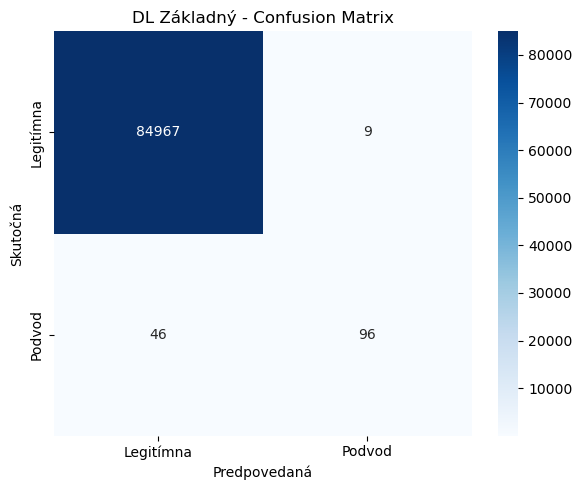

In [25]:
# Vytvorenie, natrénovanie a vyhodnotenie modelu DL
model_dl = keras.Sequential([
    keras.Input(shape=(X_tr.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_dl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Recall', 'Precision']
)

model_dl.fit(
    X_tr, y_tr,
    epochs=15,
    batch_size=2048,
    validation_data=(X_val, y_val),
    verbose=1
)

y_pred_dl = (model_dl.predict(X_test_scaled) > 0.5).astype(int)
evaluate_model(y_test, y_pred_dl, 'Deep Learning')
plot_confusion_matrix(y_test, y_pred_dl, 'DL Základný - Confusion Matrix')

In [26]:
# Výpočet váh tried pre vylepšený DL model s dôrazom na menšinovú triedu
neg = (y_tr == 0).sum()
pos = (y_tr == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print(f'Class weight pre podvody (1): {class_weight[1]:.1f}')

model_dl_opt = keras.Sequential([
    keras.Input(shape=(X_tr.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_dl_opt.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['Recall', 'Precision']
)

model_dl_opt.summary()

Class weight pre podvody (1): 598.6


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - Precision: 0.0098 - Recall: 0.8566 - loss: 0.7080 - val_Precision: 0.1827 - val_Recall: 0.8636 - val_loss: 0.1206
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - Precision: 0.0329 - Recall: 0.8792 - loss: 0.5108 - val_Precision: 0.0619 - val_Recall: 0.9091 - val_loss: 0.1524
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - Precision: 0.0455 - Recall: 0.9057 - loss: 0.3531 - val_Precision: 0.0836 - val_Recall: 0.8636 - val_loss: 0.0743
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - Precision: 0.0456 - Recall: 0.9245 - loss: 0.3478 - val_Precision: 0.1186 - val_Recall: 0.8788 - val_loss: 0.0711
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - Precision: 0.0507 - Recall: 0.9245 - loss: 0.2777 - val_Precision: 0.0623 - val_Recall: 0.9394 - val_loss: 0.0934
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - Precision: 0.0387 - Recall: 0.9283 - loss: 0.2723 - val_Precision: 0.0522 - val_Recall: 0.9242 - val

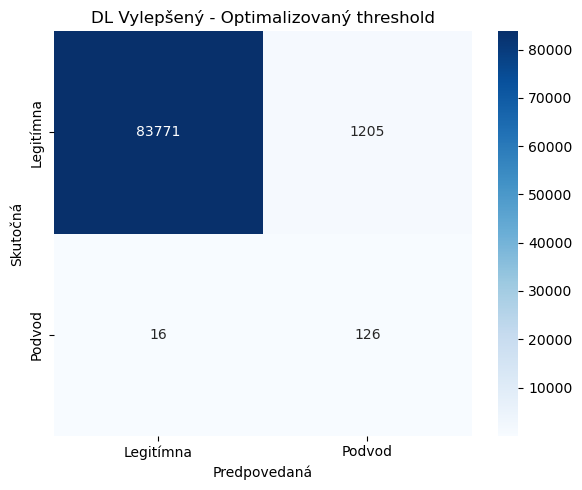

In [27]:
# Trénovanie vylepšeného DL modelu s dropout vrstvami, váhami tried a early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_dl_opt.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=1024,
    validation_data=(X_val, y_val),
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

y_proba_dl_opt = model_dl_opt.predict(X_test_scaled).flatten()

y_proba_val_dl = model_dl_opt.predict(X_val).flatten()
best_thresh_dl  = find_best_threshold_recall(y_val, y_proba_val_dl, min_precision=0.1)

y_pred_dl_tuned = (y_proba_dl_opt >= best_thresh_dl).astype(int)

print(f'Optimálny threshold (z val. sady): {best_thresh_dl:.4f}')
evaluate_model(y_test, y_pred_dl_tuned, 'DL Vylepšený - threshold tuned')
plot_confusion_matrix(y_test, y_pred_dl_tuned, 'DL Vylepšený - Optimalizovaný threshold')

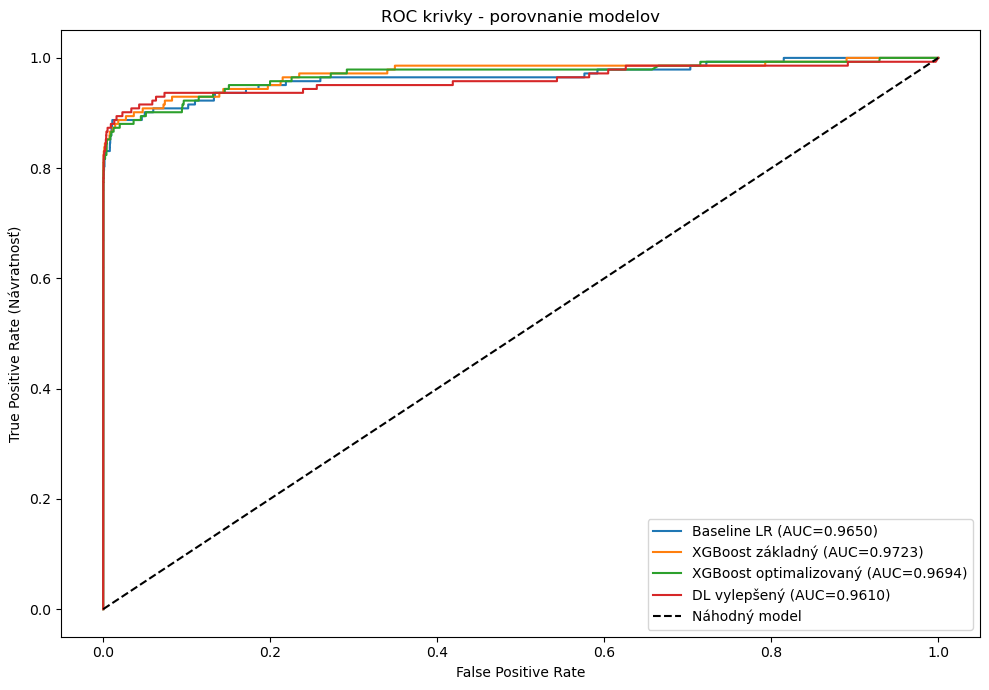

In [28]:
# Vykreslenie ROC kriviek pre porovnanie diskriminačnej schopnosti modelov
plt.figure(figsize=(10, 7))

models_proba = [
    ('Baseline LR', y_proba_base),
    ('XGBoost základný', y_proba_xgb),
    ('XGBoost optimalizovaný', y_proba_xgb_opt),
    ('DL vylepšený', y_proba_dl_opt),
]

for name, proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Náhodný model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Návratnosť)')
plt.title('ROC krivky - porovnanie modelov')
plt.legend()
plt.tight_layout()
plt.show()

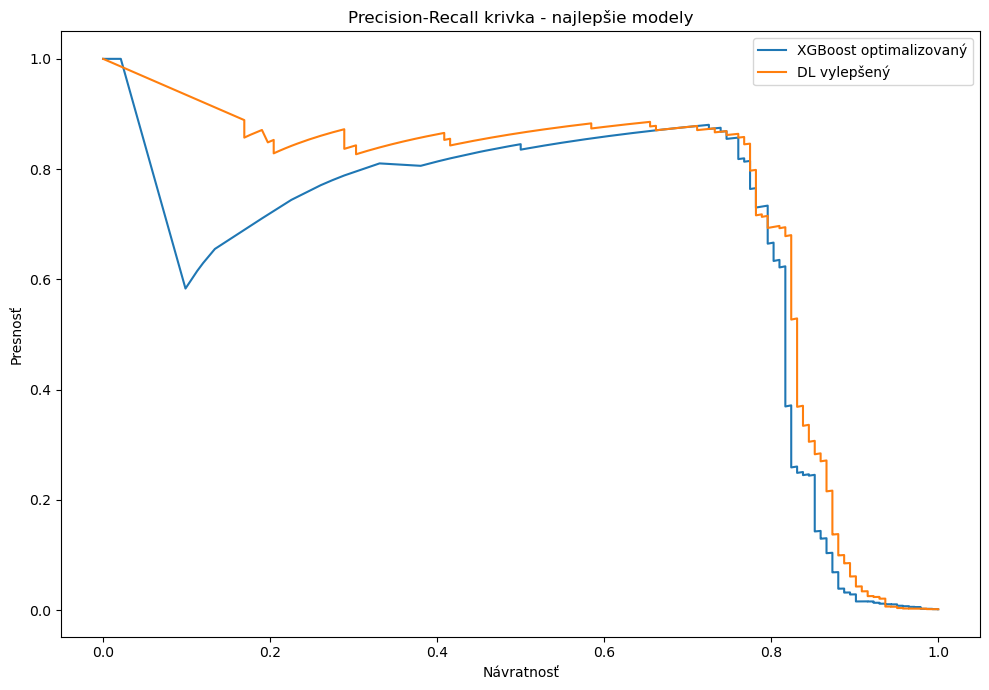

In [29]:
# Vykreslenie Precision–Recall kriviek na porovnanie modelov
plt.figure(figsize=(10, 7))

models_prc = [
    ('XGBoost optimalizovaný', y_test, y_proba_xgb_opt),
    ('DL vylepšený', y_test, y_proba_dl_opt),
]

for name, y_true, proba in models_prc:
    precisions, recalls, _ = precision_recall_curve(y_true, proba)
    plt.plot(recalls, precisions, label=name)

plt.xlabel('Návratnosť')
plt.ylabel('Presnosť')
plt.title('Precision-Recall krivka - najlepšie modely')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Tabuľka s výsledkami všetkých testovaných modelov
all_models = [
    ('Baseline LR', y_test, y_pred_base),
    ('Baseline LR - threshold tuned', y_test, y_pred_base_tuned),
    ('XGBoost základný', y_test, y_pred_xgb),
    ('XGBoost - SMOTE', y_test, y_pred_xgb_smote),
    ('XGBoost optimalizovaný', y_test, y_pred_xgb_opt),
    ('XGBoost opt. + thresh tuned', y_test, y_pred_xgb_tuned),
    ('DL vylepšený - thresh tuned', y_test, y_pred_dl_tuned),
]

rows = []
for name, y_true, y_pred in all_models:
    rows.append({
        'Model': name,
        'Návratnosť': round(recall_score(y_true, y_pred), 4),
        'Presnosť': round(precision_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'EFL': compute_efl(y_true, y_pred),
    })

results_df = pd.DataFrame(rows)
print('Porovnanie všetkých modelov:')
results_df

Porovnanie všetkých modelov:


,Model,Návratnosť,Presnosť,F1,EFL
0,Baseline LR,0.8873,0.0516,0.0975,13180
1,Baseline LR - threshold tuned,0.8873,0.0984,0.1772,7370
2,XGBoost základný,0.7535,0.9554,0.8425,3525
3,XGBoost - SMOTE,0.7746,0.8943,0.8302,3265
4,XGBoost optimalizovaný,0.8169,0.5979,0.6905,2990
5,XGBoost opt. + thresh tuned,0.8732,0.1026,0.1836,7225
6,DL vylepšený - thresh tuned,0.8873,0.0947,0.1711,7625


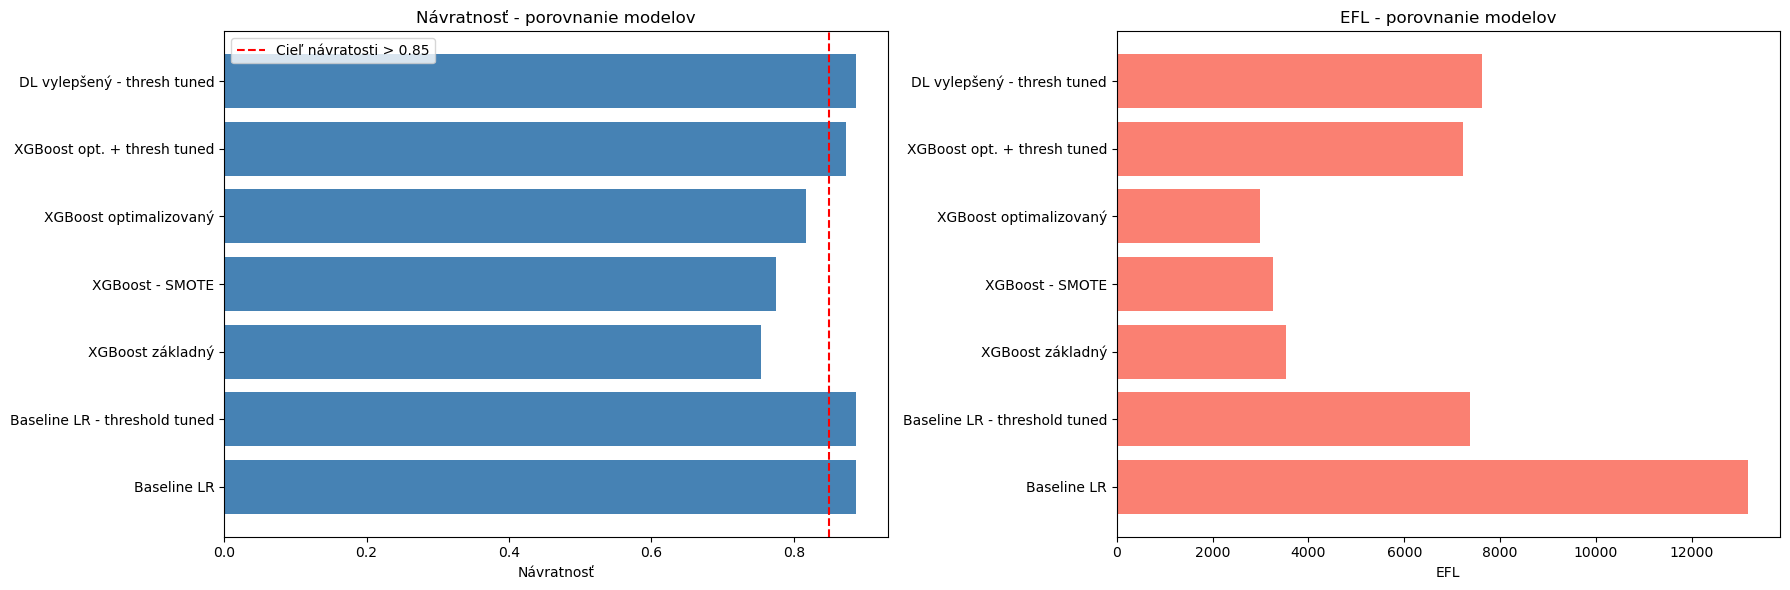

In [33]:
# Grafické porovnanie modelov podľa návratnosti a očakávanej finančnej straty
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(results_df['Model'], results_df['Návratnosť'], color='steelblue')
axes[0].set_xlabel('Návratnosť')
axes[0].set_title('Návratnosť - porovnanie modelov')
axes[0].axvline(x=0.85, color='red', linestyle='--', label='Cieľ návratosti > 0.85')
axes[0].legend()

axes[1].barh(results_df['Model'], results_df['EFL'], color='salmon')
axes[1].set_xlabel('EFL')
axes[1].set_title('EFL - porovnanie modelov')

plt.tight_layout()
plt.show()